# Assignment3 - Supervised Learning - model training and evaluation

**Name:** Edward Huang  
**NetID:** yh475  
**Collaborators:** N/A


---
## Exercise 1 - Classification using logistic regression: build it from the ground up

**1.1 Load the data** 

Text(0.5, 1.0, 'Training Data Visualization')

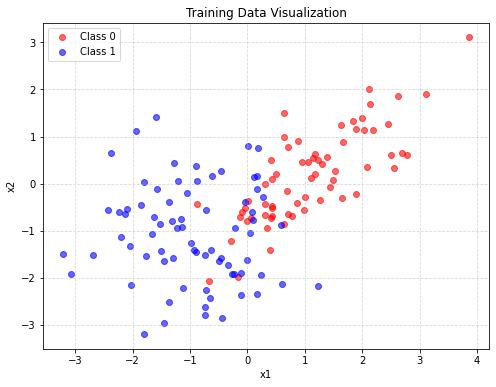

In [33]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/A3_Q1_data.csv")
x = df[['x1', 'x2']].values
y = df['y'].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(x_train[y_train == 0][:, 0], x_train[y_train == 0][:, 1], color='red', label='Class 0', alpha=0.6)
plt.scatter(x_train[y_train == 1][:, 0], x_train[y_train == 1][:, 1], color='blue', label='Class 1', alpha=0.6)
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Training Data Visualization')

Based on teh scatter plot, the two classes of data have some overlap in the feature space. The data appear to be not perfectly linear separable. However, logistic regression is still a good choice for these data because the overall distribution follows a clear linear trend.

**1.2**



In [34]:
print("Miss values in each column")
print(df.isnull().sum())

print("\nFeature statistics:")
print(df[['x1', 'x2']].describe())

Miss values in each column
x1    0
x2    0
y     0
dtype: int64

Feature statistics:
               x1          x2
count  200.000000  200.000000
mean     0.151376   -0.385426
std      1.411722    1.217490
min     -3.210005   -3.193456
25%     -0.912029   -1.341047
50%      0.112286   -0.479684
75%      1.174400    0.495114
max      3.867647    3.103541


I checked teh dataset for missing values using df.isnull().sum() and found that there are no missing entires across all columns. Regarding the scale of the features, the descriptive statistics show that both x1 and x2 have similar ranges and standard deviation. Since the scale are already comparable, extensive preprocessing like standarization is not strickly mandatory for convergence, though it remains a good practice. No other significant dat quality issue were identified. The data is ready for model fitting.

**1.3**

We assume that all N observations are independent and identically distributed. the total likelihood is the product of the individual likelihood for each training sample.       

For the single training sample, the likelihood is given by      
$$P(y_i | x_i; w) = [f(x_i, w)]^{y_i} \cdot [1 - f(x_i, w)]^{1-y_i}$$
For the entire dataset of N sample, the total likelihood function L(w) is       
$$L(w) = \prod_{i=1}^{N} P(y_i | x_i; w)$$
Substituting the individual likelihood,
$$L(w) = \prod_{i=1}^{N} \left( [f(x_i, w)]^{y_i} \cdot [1 - f(x_i, w)]^{1-y_i} \right)$$

**1.4**     

1. Since the logarithm is a monotonic function, maximizing the likelihood $L(w)$ is equivalent to maximizing the log-likelihood $\ln L(w)$. This transforms the product of probabilities into a sum of log-probabilities, which is computationally more stable and easier to differentiate.
$$\ln L(w) = \ln \left( \prod_{i=1}^{N} [f(x_i, w)]^{y_i} \cdot [1 - f(x_i, w)]^{1-y_i} \right)$$

$$\ln L(w) = \sum_{i=1}^{N} \left[ y_i \ln(f(x_i, w)) + (1 - y_i) \ln(1 - f(x_i, w)) \right]$$

2. We typically prefer to minimize a cost function. Therefore, we define the cost $J(w)$ as the negative of the log-likelihood.     
3. And we need to divied by N. The final Cost function J(w) is

$$J(w) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \ln(f(x_i, w)) + (1 - y_i) \ln(1 - f(x_i, w)) \right]$$

**1.5**

Let $\hat{y}_i = f(x_i, w)$ denote the predicted probability for the $i$-th sample, where $\hat{y}_i = \sigma(w^\top x_i)$. To minimize the cost function $J(w)$, we use the gradient descent algorithm. The update rule for each weight $w_j$ is:$$w_j := w_j - \alpha \frac{\partial J(w)}{\partial w_j}$$
Where $\alpha$ is the learning rate.        

The average cost function per sample is:$$J(w) = -\frac{1}{N} \sum_{i=1}^{N} [y_i \ln(\hat{y}_i) + (1 - y_i) \ln(1 - \hat{y}_i)]$$To find the gradient, we apply the chain rule. Given that the derivative of the Sigmoid function is $\frac{d\sigma(z)}{dz} = \sigma(z)(1-\sigma(z))$      
The partial derivative with respect to $w_j$ simplifies to:$$\frac{\partial J(w)}{\partial w_j} = \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i) x_{ij}$$

Substituting the gradient back into the update rule, we obtain the update equation for each parameter.

$$w_j := w_j - \alpha \frac{1}{N} \sum_{i=1}^{N} (\hat{y}_i - y_i) x_{ij}$$
In vectorized form, which is more efficient for implementation:     
$$w := w - \frac{\alpha}{N} X^\top (\hat{y} - y)$$

**1.6**   
      
To minimize the average cross-entropy cost function, we update the model parameters $w$ using the batch gradient descent algorithm. The update rule from the current step $k$ to the next step $k+1$ is defined as follows:

For each individual parameter $w_j$ (where $j = 0, 1, \dots, d$):$$w_j^{(k+1)} = w_j^{(k)} - \eta \frac{1}{N} \sum_{i=1}^{N} \left( \hat{y}_i^{(k)} - y_i \right) x_{ij}$$

The update for the entire weight vector $w$ can be expressed as:$$w^{(k+1)} = w^{(k)} - \frac{\eta}{N} X^\top \left( \hat{y}^{(k)} - y \right)$$

Definitions of Terms:

* $w_j^{(k)}$: The $j$-th weight at the current iteration                
* $k$.$w_j^{(k+1)}$: The updated $j$-th weight for the next iteration.        
* $\eta$: The learning rate (the "n-like" parameter).             
* $N$: The total number of training samples.              
* $\hat{y}_i^{(k)}$: The model's predicted probability for the $i$-th sample at step $k$, where $\hat{y}_i^{(k)} = \sigma\left( \sum_{j=0}^{d} w_j^{(k)} x_{ij} \right)$.             
* $y_i$: The ground truth label (0 or 1) for the $i$-th sample.           

**1.7 Implement logistic regression model**

In [35]:
import numpy as np

x_train_bias = np.hstack([np.ones((x_train.shape[0], 1)), x_train])
x_test_bias = np.hstack([np.ones((x_test.shape[0], 1)), x_test])

In [36]:
import numpy as np

class Logistic_regression:
    def __init__(self):
        self.w = None      # logistic regression weights
        self.saved_w = []  # save weights at each iteration to build learning curves
        
    # Method for calculating the sigmoid function of w^T X
    def sigmoid(self, X, w):
        z = np.dot(X, w)
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))
    
    # Cost function for an input set of weights
    def cost(self, X, y, w):
        n = len(y)
        y_hat = self.sigmoid(X, w)
        # Avoid log(0) with a small epsilon
        eps = 1e-15
        return -(1/n) * np.sum(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
    
    # Update the weights in an iteration of gradient descent
    def gradient_descent(self, X, y, lr):
        n = len(y)
        y_hat = self.sigmoid(X, self.w)
        
        # Vectorized gradient calculation: (1/N) * X^T * (y_hat - y)
        gradient = (1/n) * np.dot(X.T, (y_hat - y))
        
        # Calculate change and its Euclidean norm
        change = lr * gradient
        delta_w_norm = np.linalg.norm(change)
        
        # Update weights
        self.w = self.w - change
        return delta_w_norm
    
    # Fit the logistic regression model to the data through gradient descent
    def fit(self, X, y, w_init, lr, delta_thresh=1e-6, max_iter=5000, verbose=False):
        self.w = w_init
        self.saved_w = [self.w.copy()] 
        
        for i in range(max_iter):
            delta_norm = self.gradient_descent(X, y, lr)
            self.saved_w.append(self.w.copy())
            
            if verbose and i % 500 == 0:
                print(f"Iteration {i}: Cost {self.cost(X, y, self.w):.6f}")
            
            # Convergence check
            if delta_norm < delta_thresh:
                if verbose: print(f"Converged at iteration {i}")
                break
    
    # Use the trained model to predict the confidence scores (prob of positive class)
    def predict_proba(self, X):
        return self.sigmoid(X, self.w)
    
    # Use the trained model to make binary predictions
    def predict(self, X, thresh=0.5):
        # returns 1 if probability >= threshold, else 0
        return (self.predict_proba(X) >= thresh).astype(int)
    
    # Stores the learning curves from saved weights from gradient descent
    def learning_curve(self, X, y):
        # Calculate cross-entropy cost for every weight vector saved during training
        costs = [self.cost(X, y, weights) for weights in self.saved_w]
        return np.array(costs)
    
    # Appends a column of ones as the first feature to account for the bias term
    def prepare_x(self, X):
        ones = np.ones((X.shape[0], 1))
        return np.hstack([ones, X])

**1.8**

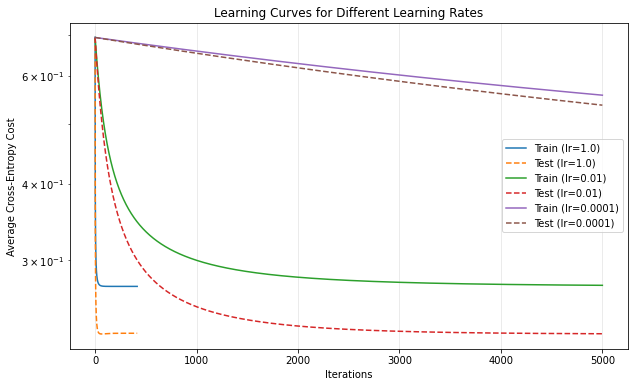

--- Weights Analysis for lr = 100 ---
Iteration 0: Weights = [0. 0. 0.]
Iteration 1: Weights = [  2.85714286 -51.39319816 -32.37769548]
Iteration 2: Weights = [ -4.20114259 -50.65188898 -21.27247268]
Iteration 3: Weights = [ -6.42943104 -47.45002453 -14.5763277 ]
Iteration 4: Weights = [ -5.46591081 -43.44333737 -11.39394314]
Iteration 5: Weights = [ -3.90610103 -39.39319228  -8.6451404 ]
Iteration 6: Weights = [ -2.35504166 -35.33127921  -5.96834632]
Iteration 7: Weights = [ -0.62703768 -31.21138797  -3.75625642]
Iteration 8: Weights = [  0.95157713 -27.03673333  -1.94156414]
Iteration 9: Weights = [  2.01678912 -22.84704979  -0.63126679]


In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Initialize and prepare data
lr_model = Logistic_regression()
x_train_bias = lr_model.prepare_x(x_train)

# Prepare data with bias term
X_train_final = lr_model.prepare_x(x_train)
X_test_final = lr_model.prepare_x(x_test)
w_init = np.zeros(X_train_final.shape[1])

# Define learning rates for comparison
lrs = [1e0, 1e-2, 1e-4]
plt.figure(figsize=(10, 6))

for lr in lrs:
    temp_model = Logistic_regression()
    temp_model.fit(X_train_final, y_train, w_init=w_init, lr=lr, max_iter=5000)
    
    # Get average cost per sample for both sets
    train_costs = temp_model.learning_curve(X_train_final, y_train)
    test_costs = temp_model.learning_curve(X_test_final, y_test)
    
    plt.plot(train_costs, label=f'Train (lr={lr})')
    plt.plot(test_costs, label=f'Test (lr={lr})', linestyle='--')

plt.yscale('log')
plt.xlabel('Iterations')
plt.ylabel('Average Cross-Entropy Cost')
plt.title('Learning Curves for Different Learning Rates')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Analysis of Extreme Learning Rate (10^2)
print("--- Weights Analysis for lr = 100 ---")
big_lr_model = Logistic_regression()
big_lr_model.fit(X_train_final, y_train, w_init=w_init, lr=100, max_iter=50)

for i, weights in enumerate(big_lr_model.saved_w[:10]): # Showing first 10 for brevity
    print(f"Iteration {i}: Weights = {weights}")

1. Analysis of the Extreme Case ($\eta = 10^2$)     

    When the learning rate is set to $10^2$, the model fails to converge. The weights exhibit extreme instability. Jumping from 0 to very large magnitudes like -51 in a single iteration. This usually triggers numercial overflow warnings as the values become too large for the sigmoid function to handle. 

    Unlike  $\eta = 10^0$, which generally moves toward the minimum,  $\eta = 10^0$ cauases the update tot overshoot the global minimum entirely. Because the step size is much larger than the width of the cost function. Instead of descending the gradient, the weights land on an even higher point on the opposite side of the curve during each update, leading to divergence rather converge.

2. Impact of learning rate on speed and results

    For the large $\eta (10^0)$, it reach a low cost very quickly. As seen in the output, the process often triggers the convergence threshold and stop well before the 5,000 iteration limit.      
    For the small $\eta (10^-4)$, the process is painfully slow. The cost decreases at a negligible rate, and the model remains far from the optimal solution even after 5,000 iterations.          

    Therefore, high learning rate risk bouncing around the minimum or divergence. On the other hand, low learning rate lead to underfitting, where the model hasn't learned enough within the given time to make accurate predictions.


3. Preferred learning ratet and justification

    I will choose  $\eta = 10^-2$ because it converges signigicantly faster than others. Also, it reaches the minimum smoothly without the wild oscillations seen in much larger rates. So  $\eta = 10^-2$ is nearly identical.

**1.9 Cross validation performance evaluation**

1. Decision Boundary Plots (Train vs Test)

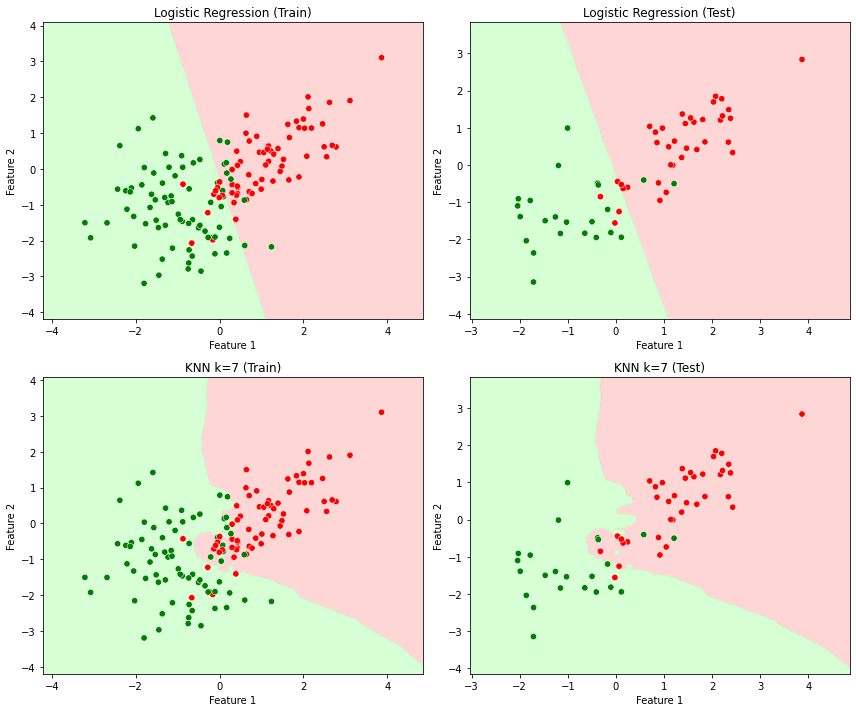

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from matplotlib.colors import ListedColormap

chosen_lr = 1e-2
lr_model.fit(X_train_final, y_train, w_init=w_init, lr=chosen_lr, max_iter=5000)

def plot_decision_boundary(model, X, y, title, is_knn=False):
    h = .02  
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    
    if is_knn:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    else:
        X_mesh = np.c_[xx.ravel(), yy.ravel()]
        X_mesh_bias = np.hstack([np.ones((X_mesh.shape[0], 1)), X_mesh])
        Z = model.predict(X_mesh_bias)
        
    Z = Z.reshape(xx.shape)

    colors = ['#FFCCCC', '#CCFFCC']  
    point_colors = ['red', 'green']
    custom_cmap = ListedColormap(colors)
    point_cmap = ListedColormap(point_colors)

    plt.contourf(xx, yy, Z, cmap=custom_cmap, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='white', linewidth=0.5, cmap=point_cmap, s=40)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

# Plotting
plt.figure(figsize=(12, 10))

# Fit KNN once for visualization
knn = KNeighborsClassifier(n_neighbors=7).fit(x_train, y_train)

plt.subplot(2, 2, 1)
plot_decision_boundary(lr_model, x_train, y_train, "Logistic Regression (Train)")
plt.subplot(2, 2, 2)
plot_decision_boundary(lr_model, x_test, y_test, "Logistic Regression (Test)")
plt.subplot(2, 2, 3)
plot_decision_boundary(knn, x_train, y_train, "KNN k=7 (Train)", is_knn=True)
plt.subplot(2, 2, 4)
plot_decision_boundary(knn, x_test, y_test, "KNN k=7 (Test)", is_knn=True)

plt.tight_layout()
plt.show()

2. ROC Curve (10-Fold)

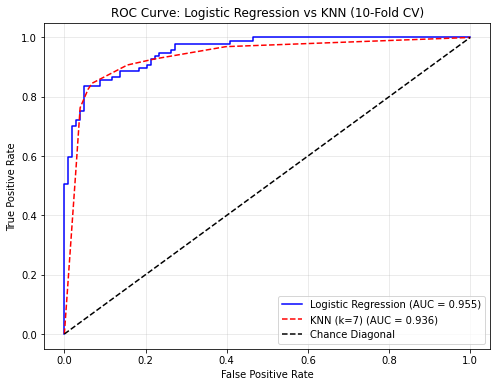

In [39]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import StratifiedKFold

# Setup 10-fold CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
all_y_true = []
lr_probs = []
knn_probs = []

# Iterative Training and Probability Collection
for train_idx, test_idx in cv.split(x, y):
    # Split
    X_train_cv, X_test_cv = x[train_idx], x[test_idx]
    y_train_cv, y_test_cv = y[train_idx], y[test_idx]
    
    # Fit Logistic Regression
    lr = Logistic_regression()
    X_train_bias_cv = lr.prepare_x(X_train_cv)
    X_test_bias_cv = lr.prepare_x(X_test_cv)
    lr.fit(X_train_bias_cv, y_train_cv, w_init=np.zeros(3), lr=0.1)
    
    # Fit KNN
    knn = KNeighborsClassifier(n_neighbors=7)
    knn.fit(X_train_cv, y_train_cv)
    
    # Store results
    all_y_true.extend(y_test_cv)
    lr_probs.extend(lr.predict_proba(X_test_bias_cv))
    knn_probs.extend(knn.predict_proba(X_test_cv)[:, 1])

# Calculate metrics
fpr_lr, tpr_lr, _ = roc_curve(all_y_true, lr_probs)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_knn, tpr_knn, _ = roc_curve(all_y_true, knn_probs)
auc_knn = auc(fpr_knn, tpr_knn)

# 4. Final Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='blue')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (k=7) (AUC = {auc_knn:.3f})', color='red', linestyle='--')
plt.plot([0, 1], [0, 1], 'k--', label='Chance Diagonal')

plt.title('ROC Curve: Logistic Regression vs KNN (10-Fold CV)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

3. What is the purpose of using cross validation for this problem?   
   
    The primary purpose of cross validation is to obtain a more reliable and robust estimate of the model's performance on unseen data. By partitioning the data into 10 folds and rotating the data set, we ensure that every data point is used for both training anad validation. This mitigates the risk of getting a split that might happen with a single train test division, providing a more generalized assessment of the model's predictive power.

4. How do the models compare in terms of performance?           

* ROC curves and AUC:       

    * Logistic regression achieved an AUC of 0.955, which is superior to the KNN's AUC of 0.936
    * It indicates that logistic regession has a higher probabililty of correctly ranking a random positive instance higher than a random negative instance across various classificaion thresholds.

* Decision Boundaries:      

    * Logistic regression produces a linear decision boundary suggesting that the underlying relationship in this dataset is likely linera
    * KNN produces a non linear boundary that follows local data density. While it captures more detail, it appears more jagged compared to the stable line of logistic regression model.

5. Which model would you select to use on previously unseen data for this problem?      
    
    I would select the logistic regression model for deployment on unseen data. Becuase it has higher AUC than KNN under 10-fold cross validation. Also, the linear decision boundary is simpler and appears to capture the global trend of the data well, which typically leads to better generalization and a lower risk of overfitting compared to. the more complex boundaries of KNN.

6. Confidence level

    I am highly confident in this choice becaue the 10 fold CV results provide strong statistical evdience that logistic regression is the more stable and accurate classifier for this speficic dataset. Maybe I would look at confusion matrices to see trade-off between false positives and false negatives to increase confidence.


---
## Exercise 2 - Digits classification

**2.1 Plot 10 examples**

In [9]:
# Load the MNIST Data
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pickle

# Set this to True to download the data for the first time and False after the first time 
#   so that you just load the data locally instead
download_data = True

if download_data:
    # Load data from https://www.openml.org/d/554
    X, y = fetch_openml('mnist_784', return_X_y=True, as_frame=False)
    
    # Adjust the labels to be '1' if y==3, and '0' otherwise
    y[y!='3'] = 0
    y[y=='3'] = 1
    y = y.astype('int')
    
    # Divide the data into a training and test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/7, random_state=88)
    
    file = open('tmpdata', 'wb')
    pickle.dump((X_train, X_test, y_train, y_test), file)
    file.close()
else:
    file = open('tmpdata', 'rb')
    X_train, X_test, y_train, y_test = pickle.load(file)
    file.close()

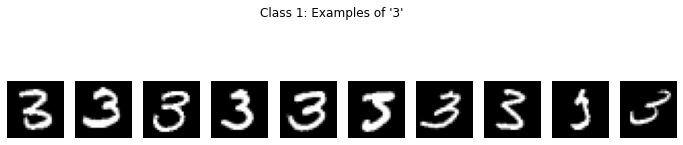

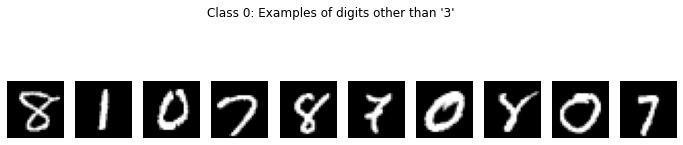

In [10]:
def plot_examples(X, y, target_class, title):
    # Find indices where the label matches our target class (0 or 1)
    indices = np.where(y == target_class)[0][:10]
    
    plt.figure(figsize=(12, 3))
    for i, idx in enumerate(indices):
        plt.subplot(1, 10, i + 1)
        # Reshape the flat 784 array back to 28x28 for plotting
        plt.imshow(X[idx].reshape(28, 28), cmap='gray')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# plot 10 example of 3
plot_examples(X_train, y_train, target_class=1, title="Class 1: Examples of '3'")

# Plot 10 examples of not 3
plot_examples(X_train, y_train, target_class=0, title="Class 0: Examples of digits other than '3'")

**2.2 How many examples are present in each class**


Negative sample(not 3): 53871
Positive sampe(is 3): 6129
Fraction of positive samples: 0.1022


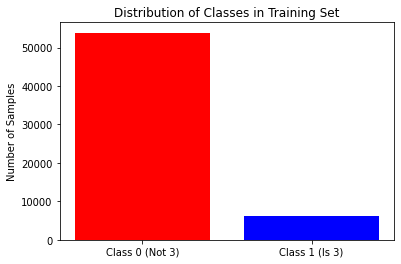

In [11]:
# Calculate every class 

counts = np.bincount(y_train)
n_neg = counts[0]
n_pos = counts[1]
total = len(y_train)

fraction_pos = n_pos / total

print(f"Negative sample(not 3): {n_neg}")
print(f"Positive sampe(is 3): {n_pos}")
print(f"Fraction of positive samples: {fraction_pos:.4f}")

#plot the bar chart
plt.figure(figsize=(6, 4))
plt.bar(['Class 0 (Not 3)', 'Class 1 (Is 3)'], [n_neg, n_pos], color=['red', 'blue'])
plt.ylabel('Number of Samples')
plt.title('Distribution of Classes in Training Set')
plt.show()

This data exhibits significant imblance, which leads to issues in the accuracy paradox. Because if a model simply predicts class 0 for every single input, it will achieve an 89.78% accuracy. This high score is deceptive because the model has failed to learn any features of the number 3, yet the metric suggests the model is performing well.       

Additionally, it may lead to model bias, most algorithms aim to minimize the overall error. Consequently the model will prioritize the majority class to reduce lose, often leading to a high false negatives.          

**2.3**

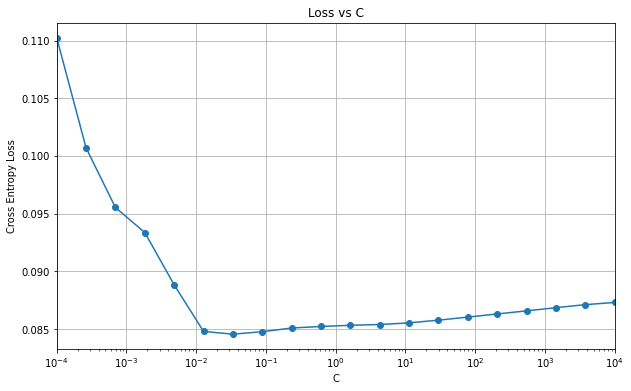

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, roc_auc_score, f1_score

c_values = np.logspace(-4, 4, 20)

non_zero_counts = []
losses = []
aucs = []
f1_scores = []

for c in c_values:
    model = LogisticRegression(penalty='l1', C=c, solver='liblinear', random_state=42)
    model.fit(X_train, y_train)
    
    non_zero = np.sum(np.abs(model.coef_) > 1e-5)
    non_zero_counts.append(non_zero)
    
    y_probs = model.predict_proba(X_test)
    y_preds = model.predict(X_test)
    
    losses.append(log_loss(y_test, y_probs))
    aucs.append(roc_auc_score(y_test, y_probs[:, 1]))
    f1_scores.append(f1_score(y_test, y_preds))

plt.figure(figsize=(10, 6))
plt.plot(c_values, losses, marker='o')
plt.xscale('log') 
plt.xlabel('C')
plt.ylabel('Cross Entropy Loss')
plt.title('Loss vs C')
plt.grid(True)
plt.xlim(1e-4, 1e4)
plt.show()

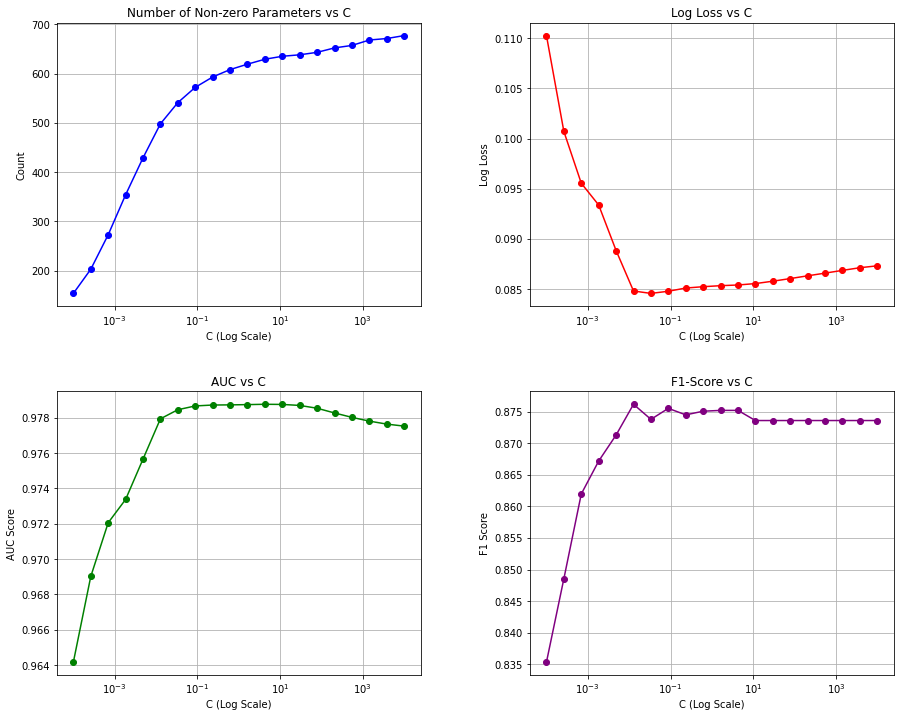

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.subplots_adjust(hspace=0.3, wspace=0.3)

axes[0, 0].plot(c_values, non_zero_counts, marker='o', color='blue')
axes[0, 0].set_xscale('log')
axes[0, 0].set_title('Number of Non-zero Parameters vs C')
axes[0, 0].set_xlabel('C')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(True)

axes[0, 1].plot(c_values, losses, marker='o', color='red')
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Log Loss vs C')
axes[0, 1].set_xlabel('C')
axes[0, 1].set_ylabel('Log Loss')
axes[0, 1].grid(True)

axes[1, 0].plot(c_values, aucs, marker='o', color='green')
axes[1, 0].set_xscale('log')
axes[1, 0].set_title('AUC vs C')
axes[1, 0].set_xlabel('C')
axes[1, 0].set_ylabel('AUC Score')
axes[1, 0].grid(True)

# 4. F1-Score
axes[1, 1].plot(c_values, f1_scores, marker='o', color='purple')
axes[1, 1].set_xscale('log')
axes[1, 1].set_title('F1-Score vs C')
axes[1, 1].set_xlabel('C (Log Scale)')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].grid(True)

plt.show()

I will choose $10^-1$. The minium loss value occurs between $10^-2$ to $10^-1$. Since the curve typically reaches its sweet spot before satr4gin to rise again due to overfitting $10^-1$ is the best choice. Additionaly, in the AUC vs C plot and the F1-socre vs c plot, the metrics reach the highest plateaus around $10^-1$.

**2.4 Train and Test a logistic regression**


1. Define 4 training model with C = 0.1

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# Model 1 Logistic regression with minimal regularization
lr_min_reg = LogisticRegression(penalty='l1', C=1e100, solver='liblinear', random_state=42)
lr_min_reg.fit(X_train, y_train)

# Model 2 Logistic regression with c = 0.1
lr_best_reg = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', random_state=42)
lr_best_reg.fit(X_train, y_train)

# Model 3 Gradient Boosting classifier
gbc = GradientBoostingClassifier(random_state=42)
gbc.fit(X_train, y_train)

# Model 4 Random forest classifier
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

2. Estimate the probability scores

In [17]:
probs = {"LR (Minimal Reg)": lr_min_reg.predict_proba(X_test)[:, 1],
         "LR (Best C=0.1)": lr_best_reg.predict_proba(X_test)[:, 1],
         "Gradient Boosting": gbc.predict_proba(X_test)[:, 1],
         "Random Forest": rfc.predict_proba(X_test)[:, 1]
        }

3. Compare classifiers' performance using ROC and precision recall curves.

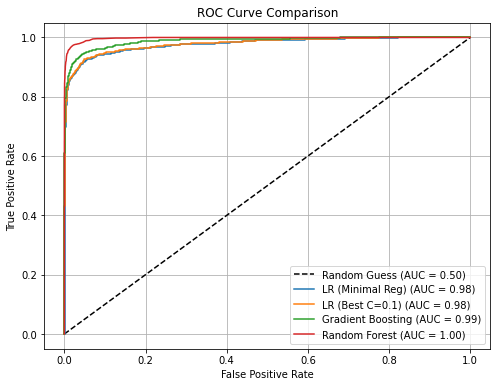

In [18]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.50)')

for name, y_score in probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

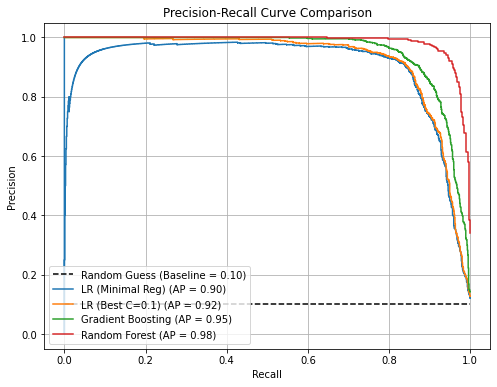

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

prevalence = y_test.mean() 
plt.plot([0, 1], [prevalence, prevalence], 'k--', label=f'Random Guess (Baseline = {prevalence:.2f})')

for name, y_score in probs.items():
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    plt.step(recall, precision, where='post', label=f'{name} (AP = {ap:.2f})')

plt.title('Precision-Recall Curve Comparison')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

4. Performance Summary

- Logistic Regression (minimum regression): Show AUC 0.98 but has the lowest PR performance AP 0.9
- Logistic Regression (C = 0.1): Perform same AUC 0.98 with minimum regression and better AP of 0.92
- Gradient Boosting: Better AUC 0.99 and AP of 0.95
- Random Forest: This is the best performing mode, achieving a near perfect AUC of 1 and highest AP of 0.98

5. Impact of Regularization

    The regulization of the logistic regression model made a noticeable difference in the PR curve. With both model have the same AUC of 0.98, the C = 0.1 model achieved better AP.        
    This suggests that applying lasson reguarization and removing noisy features, the model became more preciesely.

6. Classifier selection for unseen data

    The random forest classifier is the best choice based on these metrics. Because it maintains the highest precision.

**2.5 Measure of uncertainty by boostrap**

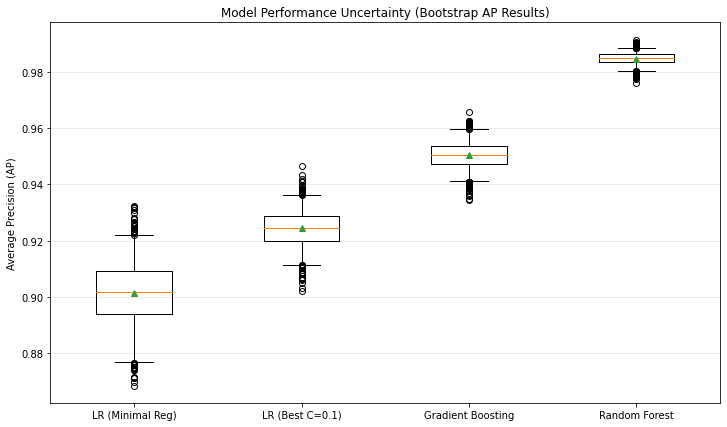

In [25]:
from sklearn.utils import resample

models = {
    "LR (Minimal Reg)": lr_min_reg,
    "LR (Best C=0.1)": lr_best_reg,
    "Gradient Boosting": gbc,
    "Random Forest": rfc
}

n_bootstraps = 1000
bootstrap_indices = np.arange(len(y_test))
model_ap_results = {name: [] for name in models.keys()}

for i in range(n_bootstraps):
    # Resample with replacement to create a 'virtual' test set
    idx = resample(bootstrap_indices, replace=True, n_samples=len(y_test), random_state=i)
    X_boot, y_boot = X_test[idx], y_test[idx]
    
    for name, model in models.items():
        # Get probability estimates for the positive class ("3")
        y_probs = model.predict_proba(X_boot)[:, 1]
        
        # Calculate Average Precision (AP) for this specific sample
        ap = average_precision_score(y_boot, y_probs)
        model_ap_results[name].append(ap)


plt.figure(figsize=(12, 7))
plt.boxplot(model_ap_results.values(), 
            labels=model_ap_results.keys(), 
            whis=[2.5, 97.5], 
            showmeans=True)

plt.title('Model Performance Uncertainty (Bootstrap AP Results)')
plt.ylabel('Average Precision (AP)')
plt.grid(axis='y', alpha=0.3)
plt.show()